# BDM550 Text Mining - Final Project Question 1

Group members: Andrey Kudritskiy, Michelle Cong, Lihn Le, Jacob Balch

#### Helpful resources used:
* https://www.youtube.com/playlist?list=PLQY2H8rRoyvzDbLUZkbudP-MFQZwNmU4S - NLP Introduction to Tensorflow / Keras (the first two videos in this playlist are must a must watch)
* also found these, but rather late:

https://www.tensorflow.org/text/tutorials/nmt_with_attention

https://www.tensorflow.org/text/tutorials/transformer

## Libraries/Dependencies

**Quick note before starting**

For the tensorflow to use a gpu instead of a cpu...

* Hosting Notebook/Jupyter in wsl2 --> tf stopped cuda support for windows in version 2.10 (Getting Tensorflow to work with Cuda on native windows is very difficult because support for it has stopped)
* Nvida graphics card compatible with CUDA.
* CUDA and Nvida drivers instealled

This is useful because gpu's are optimized for tasks such as matrix manipulations, dot products, vectorization calculations,etc....
It is perciscely these computations which occur in the tensorflow package. What's more important than even that is that GPU's are capable optimized for parallel computtation, making further improvements to compute speed. There is an immense noticeable difference when running tensorflow code on a cpu compared to a gpu. Fortuneatly the library does alot of heavy lifting as a lot of these optimizations are done for us under the hood. in the same function calls/methods.

***please make sure that the notebook has a file named my_model.keras or my_model_v2.keras in the same working directory as this notebook***

In [ ]:
import os
target_file = 'my_model_v2.keras'

if target_file in os.listdir():
    print("Found existing model, you're good to go'")
else:
    print("Please find the my_model.keras with the submission on blackboard")

Please find the my_model.keras with the submission on blackboard


In [ ]:
import tensorflow as tf

print("Is built with CUDA:", tf.test.is_built_with_cuda())
print("GPUs found:", tf.config.list_physical_devices('GPU'))

Is built with CUDA: True
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.models import load_model, save_model
from sklearn.metrics import accuracy_score
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu

In [ ]:
#fr_path = "Sentence pairs in English-French - 2025-11-29.tsv" #I chose french, because I know french. --> only if there's time
ru_path = "Sentence pairs in English-Russian - 2025-11-29.tsv" # same with Russian. -->lucky me, russian is the second largest corpus after english.Frennch not far behind
#It's easier to validate and interpret results if I know thelanguage
#I keep as much of the ipynb in english for peolpe who only understand english.

#df_fr = pd.read_csv(fr_path, sep="\t", engine="python", on_bad_lines="skip", header=None)#for now I'm dealing with only russian as I build out the code.
df_ru = pd.read_csv(ru_path, sep="\t", engine="python", on_bad_lines="skip", header=None)
#df_fr = pd.read_csv(fr_path,sep="\t", engine="python", on_bad_lines="skip", header=None)

df = df_ru.copy()
df.head()

,0,1,2,3
0,1276,Let's try something.,5409,Давайте что-нибудь попробуем!
1,1277,I have to go to sleep.,5410,Мне пора идти спать.
2,1277,I have to go to sleep.,2034633,Я должен ложиться спать.
3,1280,Today is June 18th and it is Muiriel's birthday!,5413,"Сегодня 18 июня, и это день рождения Мюриэл!"
4,1282,Muiriel is 20 now.,5415,Мюриэл сейчас 20.


In [ ]:
df.dtypes

,0
0,int64
1,object
2,int64
3,object


In [ ]:
df.shape

(787439, 4)

In [ ]:
df.columns = ["eng_id","eng_sent","rus_id","rus_sent"]
df.head()

,eng_id,eng_sent,rus_id,rus_sent
0,1276,Let's try something.,5409,Давайте что-нибудь попробуем!
1,1277,I have to go to sleep.,5410,Мне пора идти спать.
2,1277,I have to go to sleep.,2034633,Я должен ложиться спать.
3,1280,Today is June 18th and it is Muiriel's birthday!,5413,"Сегодня 18 июня, и это день рождения Мюриэл!"
4,1282,Muiriel is 20 now.,5415,Мюриэл сейчас 20.


In [ ]:
df.isna().sum()# we don't mind missing values, we can treate missing words as they are. a missing word. the model in theory can support that

,0
eng_id,0
eng_sent,0
rus_id,0
rus_sent,0


## Data Prep


* column 0 represents the english sentence id in the tatoeba database
* column 1 represents the english sentence itself
* column 2 represents the russian sentence id in the tatoeba database
* column 3 represents the russian sentence itself

Dropping unesseray columns: column 0 and 2. These are useful for pairing the correct sentences together, however we already have our sentence pairs so these two variables only increase the dimensionality of our data, while also holding no value adding unwanted noise to any models we create.

We won't really have a need to map these values back to anything either, there is no reason to keep them moving forward.

In [ ]:
df.drop(["eng_id","rus_id"],axis=1)

,eng_sent,rus_sent
0,Let's try something.,Давайте что-нибудь попробуем!
1,I have to go to sleep.,Мне пора идти спать.
2,I have to go to sleep.,Я должен ложиться спать.
3,Today is June 18th and it is Muiriel's birthday!,"Сегодня 18 июня, и это день рождения Мюриэл!"
4,Muiriel is 20 now.,Мюриэл сейчас 20.
...,...,...
787434,"The movie was just middling, not great or terr...","Фильм был средненький, не супер, но и не ужасный."
787435,"Come on, you can do better than this!","Давайте, вы можете лучше!"
787436,"Come on, you can do better than this!","Давай, ты можешь лучше!"
787437,I'd tell you if I knew.,"Я бы тебе сказал, если бы знал."


Intresting note: both of these sentences are identical in english, but differ in russian.</br>
I'd tell you if I knew. --> Я бы тебе сказал, если бы знал.</br>
I'd tell you if I knew. --> Я бы вам сказал, если бы знал.</br>
This is because when addressing some one older or with respect you would use a plural form of you as apposed to singular. It's the same grammatical logic found in french. ("тебе"/"вам" or in french "toi"/"vous"...)

#### Seperating Data into training and test splits

* training split is used to train the model
* test set used to test the model when it's finished training/tuning.
* validate (val for short) is used to tune the model's specific weights/nodes... as with each epoch that goes by in a nueral net, the validation set will be used to measure if the accuracy as it increases and the loss/error as it decreases. (at least that's the goal).

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    shuffle=True
)


val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

#70% train, 15% val and test respectively.
print(len(df), "total")
print(len(train_df), "train")
print(len(val_df), "validation")
print(len(test_df), "test")

787439 total
551207 train
118116 validation
118116 test


## Simple Seq2Seq with a LSTM model

*note: although the project description appeared as step 4 for evaluating our transformer model that will will build. We chose to start with a LSTM model as it's simpler and therfore easier to explain what every step does. since many of the preprocessing steps are the same in our LSTM as it would be with our transformer model. it felt more natural and it's not necesarally contradicting the instrictuons*

We are starting with a simple approach of sequence to sequence (english set of words forming a sentence as the first sequence, russian as the second). and we are implementing it through a Long Short-Term Memory (LSTM) Recurrent nerual netowrk (RNN).

This approach is a good one for the given task of translating short sentences. because RNN are capable of keeping track of previous words and guessing the next, for instance: Happy is often followed by birthday. being able to remember past words in a model can help better understand larger windows of context. for instance George was **happy**, because it was his **birthday**.

#### Tokenizing English and Russian sentences (russian can be any other language here)

Instead of using nltk like we would usally do, Tensorflow has it's own tokenizing method.
Default behaviour is to remove punctuation and remove capitlization, but it does not remove stop words this is a good thing as we want to stopwrods as they are important for the sake of cohesion, word order and sentence structure, when translating between languages this is crucial.

This will be used as a simple baseline model we will compare a transformer model to later.

The tokenize() method from keras has several parameters to adjust... for this project we will just keep things simple and stick with the defaults
* filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
* lower=True,
* split=' '

the only parameter we will actually specify is oov_token="\<OOV\>". more on that later. (scroll down)

more found here: </br>
https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer

In [ ]:
eng_tokenizer = Tokenizer(oov_token="<OOV>")
rus_tokenizer = Tokenizer(oov_token="<OOV>")

eng_tokenizer.fit_on_texts(train_df["eng_sent"])
rus_tokenizer.fit_on_texts(train_df["rus_sent"])

***Important note: it's very important that we only applied the tokenizer to the training set***
this will be more apparent as to why later.

In [ ]:
#A few examples of what is going on under the hood in the tokenizer method
print(type(eng_tokenizer.word_index))
print(list(eng_tokenizer.word_index.items())[:10])
print(list(eng_tokenizer.word_counts.items())[:10])
print(eng_tokenizer.document_count)

<class 'dict'>
[('<OOV>', 1), ('you', 2), ('i', 3), ('to', 4), ('the', 5), ('tom', 6), ('a', 7), ('is', 8), ('that', 9), ('do', 10)]
[('do', 40749), ('be', 19243), ('kind', 1120), ('to', 122818), ('your', 20990), ('children', 2057), ('why', 10923), ('did', 17614), ('you', 133028), ('attack', 180)]
551207


#### Turning each sentence into a sequence using the tokens generated above.

After applying Tokenizer(), as seen above; we now have two important things
* a dictionary containing each word and an encoded representation itself, for instance : "you" --> 1, "i" --> 2,etc...</br>
Notice how the most common english words (most frequent) appeard first/have the lowest encoded number representation. This is to reduce future computation by making calculations as small/fast as possible for the words we will see most often. very clever.
* the second thing we have the the count of each word in our corpus of sentences. for instance "let's" has a count/frequency of 4858 in english sentences.

Now we want to take those word encodings and create sequences out of them to represent sentences...
* ["for", "instance", "this", "sentence"] --> {"for":15,"intsance":532,....} --> [15,532,7,34]
now we can represent the entire sentence in as a vector or... a sequence. (hence sequence to sequence modeling as we apply to both english and russian we can use one sequence to predict the other.)

In [ ]:
train_eng_seq = eng_tokenizer.texts_to_sequences(train_df["eng_sent"])
train_rus_seq = rus_tokenizer.texts_to_sequences(train_df["rus_sent"])

In [ ]:
print(train_eng_seq[:3])

[[10, 28, 368, 4, 25, 234], [50, 36, 2, 1381, 6], [3, 42, 9, 6, 3976, 103, 99]]


#### Applying the encoded tokens derived from the training set to the validation and testing sets.

We intentionally removed the test and validation sets from the training data, not only to avoid data leakage in our model (model havin acess to information in should not i.e the target variable). but also to isolate the tokenization process, because of the parameter we specified when intializing our tokenizer objects for both english and russian training sets:</br>
oov_token="\<OOV\>"</br>
This parameter specifies what to do when a word that was not in the training set appears in either the testing or validation set.
if we were not to do this then we'd end up with something like this:

Imagine that the word "Hypothetical" is new to the model, it never occured in the training data.</br>
* "hypothetical sentence here " --> ["hypthetical", 324, 43]
* we had no encoded number (key of "hypothetical") to map to in our dictionary...
  
this does not make any sense, infact it would break the logic behind what the keras tokenizer was trying to accomplish. to deal with this tensorflow has a default behaviour to simply ommit missing words from a sequence. so in reality the example above would look like this:

* "hypothetical sentence here " --> [324, 43]
however when we do this translating becomes very difficult because removing entire words can change the meaning of entire sentences:
example: "I don't love you" when missing the don't becomes "I love you" or if missing the love becomes "I don't you".

This is what the oov_token parameter fixes. it stands for "out of vocabulary". we set it to something (a string) that is very unlikely to appear in our text for instance the combination of what looks like html code: \<OOV\> it's extremly unlikely to happen uppon a string such as this unless in a program textbook.

finally what we actually want to do:
* "hypothetical sentence here " --> ["OOV", 324, 43]

now our model can use the surrounding context of the word with the added context that there is a un-known, uncommon word in a specific position of a sentence to try and look for the best translated word in our target languages vocabulary. a much better approach then simply loosing a word and therfore context and information that would never be translated.

In [ ]:
test_eng_seq = eng_tokenizer.texts_to_sequences(test_df["eng_sent"])
test_rus_seq = rus_tokenizer.texts_to_sequences(test_df["rus_sent"])

val_eng_seq = eng_tokenizer.texts_to_sequences(val_df["eng_sent"])
val_rus_seq = rus_tokenizer.texts_to_sequences(val_df["rus_sent"])

In [ ]:
first_word, first_index = next(iter(eng_tokenizer.word_index.items()))
print(first_word, first_index)

<OOV> 1


"\<OOV\>" was given the encoding of 1, probably because it was the first thing to get encoded by into the word_index dictionary.
if the param was specified to include an out of vocab placeholder, then it will always be the first enconded value.

In [ ]:
print(sum(1 for seq in test_eng_seq if 1 in seq))
print(sum(1 for seq in val_eng_seq if 1 in seq))
print(sum(1 for seq in test_rus_seq if 1 in seq))
print(sum(1 for seq in val_rus_seq if 1 in seq))
#russian clearly has a lot more distinct words... speaking from experience I'm not surprised

1865
1866
6284
6375


#### Padding sentences

What is padding? it's when you add trailing or leading 0's to a sequence to make all the dimensions of our data uniform.
* this helps with using libraries that require uniform data to be passed to them.
* this helps with computation because matrix opperations can now be completed much more efficiently than on non-uniform data. (there would be scenario's where you'd have to manually iterate over data instead of applying linear algebra to the an entire matrix)


if a sequences length ever goes over the padding limit. the rest of the words in the sequence are discarded. you can choose to do this both before and after as well (pre and post). for this model.

In [ ]:
eng_lens = np.array([len(seq) for seq in train_eng_seq])
rus_lens = np.array([len(seq) for seq in train_rus_seq])

In [ ]:
train_padded_eng = pad_sequences(train_eng_seq[0:5], maxlen=max(eng_lens), padding='pre')
train_padded_rus = pad_sequences(train_rus_seq[0:5], maxlen=max(eng_lens), padding='post')
#note that usage of pre and post should always be consistent throughout a model. both were used here just for illustrative purposes

print(type(train_padded_eng))
print(train_padded_eng[0]) #pre padding
print("\n",train_padded_rus[0]) #post padding
print(train_padded_eng.shape) #not this is only the first 5 sequences.

<class 'numpy.ndarray'>
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0  10  28 368   4  25 234]

 [ 765 2639   62  412 1008    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0 

but that's alot of zero's, in other words the zeros are going to blow up our model's dimensionality causing it to be very computationaly expensive/slow let's see if we can do anything about that

#### Deciding a maximum length for padding our sequences

In [ ]:
eng_mean = np.mean(eng_lens)
rus_mean = np.mean(rus_lens)

eng_var = np.var(eng_lens)
rus_var = np.var(rus_lens)

eng_std = np.std(eng_lens)
rus_std = np.std(rus_lens)

print("english limit:", max(eng_lens))
print("russian limit:", max(rus_lens))

print(f"english stats - mean:{eng_mean}, variance:{eng_var}, standard deviation:{rus_std}")#same deviation, english mean higher(variance too)
print(f"russian stats - mean:{rus_mean}, variance:{rus_var}, standard deviation:{rus_std}")

english limit: 206
russian limit: 148
english stats - mean:6.2383551007153395, variance:7.977633070339666, standard deviation:2.4837310726122257
russian stats - mean:5.359623517117889, variance:6.1689200410594776, standard deviation:2.4837310726122257


as we can see above the longest sequences in our dataset are massive. and are not representative of our data. we should consider removing them as outliers. otherwise we are going to slow our model down significantly for very little pay off. I'm willing to lose accuracy and reduce run time if it's this extreme.

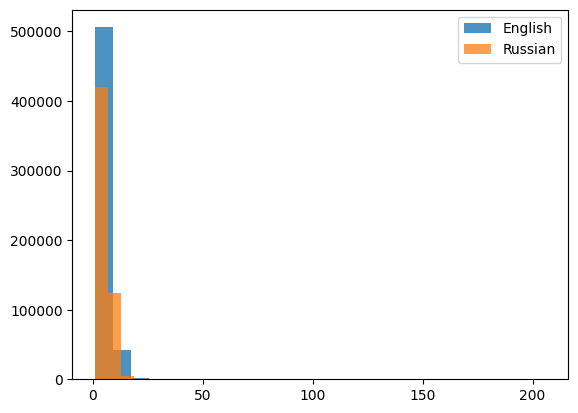

In [ ]:
plt.hist(eng_lens, label='English',bins=25, alpha=0.8)
plt.hist(rus_lens, alpha=0.75,bins=25,label='Russian')  # alpha between 0 (fully transparent) and 1 (opaque)
plt.legend()
plt.show()

Looking at the distribution of our data and it's central tendencies it's clearly safe to say that if we were to set the max to something like 4 times the standard deviation plus the mean (to be safe). --> on a normal distribution that's like 99.997% percentile...

Such an approach would let us keep almost all of our words/embeddings from our sequences; leaving out only the extreme outliers. this does probably mean that our model will not be able to translate longer sentences, however our model would have struggled to generate longer sentences due to the imbalance in the dataset caused by not many sequences being larger than 20~ words (relatively speaking). It's also worth consider longer sentences can always be broken down into smaller clauses if needed. On the other hand compared to a naive approach like taking the max() value for english sequence lengths (206). our arbitrary choice of 4 standard deviations away is only about a max padding length of 6.2383551007153395 + 2.483731072612226*4 = 16.17. so let's move forward with 4 standard deviations away from the mean.

finally we choose to use post-padding, because it is more clear to the model when shorter words end. (because by context it will see many zeros.) and it will also ensure that the important words that start the sentence are never cut off, so even if something gets truncated we know that a lot of meaning was still dilivered from the start of the sentence. the start of the sentennce is important given that LSTM's get context from what came before, and what came before is always going to be the start of the sentnce, therfore we always want to prioritize giving the model the best context.

In [ ]:
eng_max = int(eng_mean+eng_std*4) #using only english, we want the dimension to be the same between english and russian

train_padded_eng = pad_sequences(train_eng_seq, maxlen=eng_max, padding='post')
train_padded_rus = pad_sequences(train_rus_seq, maxlen=eng_max, padding='post')

test_padded_eng = pad_sequences(test_eng_seq, maxlen=eng_max, padding='post')
test_padded_rus = pad_sequences(test_rus_seq, maxlen=eng_max, padding='post')

val_padded_eng = pad_sequences(val_eng_seq, maxlen=eng_max, padding='post')
val_padded_rus = pad_sequences(val_rus_seq, maxlen=eng_max, padding='post')

In [ ]:
print(train_padded_eng[0])
train_padded_eng.shape

[ 10  28 368   4  25 234   0   0   0   0   0   0   0   0   0   0   0]


(551207, 17)

## Building the LSTM model

In [ ]:
target_file = 'my_model_v2.keras'

if target_file in os.listdir():
    print("Found existing model, importing now as 'model'")
    no_model = False
    model = load_model(target_file)
else:
    no_model=True
    print(FileNotFoundError(f"{target_file} not found"))
    print(os.listdir())
    print(f"File '{target_file}' was NOT imported to notebook...")
    print("Proceeding to construct new model for use...")

    model = Sequential([
    Embedding(
        input_dim=len(eng_tokenizer.word_index) + 1,
        output_dim=8
    ),

    LSTM(8, return_sequences=True),

    Bidirectional(LSTM(8, return_sequences=True)),
    LSTM(8, return_sequences=True),

    Dense(8, activation='relu'),

    Dense(len(rus_tokenizer.word_index) + 1, activation='softmax')
])


Found existing model, importing now as 'model'


##### Important note:

I've edited the cell meta data to import files instead of running the model if those files exist. That's because those files are the trained/compiled models.

We no longer need to run those cell blocks anymore as we can just import the my_model.keras file or the json data to view the details from training, that file is the resulting model from when the model trained the first time. This approach saves time not having re-run the model training.

the compiling cell for the model does not run at all, it's meta data has been set it to read only. this is to keep the training/epoch data. It's possible to save it, but the variables left my memory and I can't get them back.

In [ ]:
if no_model:
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',  # because targets are integers
        metrics=['accuracy'])

In [ ]:
if no_model:
    model.fit(
        train_padded_eng, train_padded_rus,
        validation_data=(val_padded_eng, val_padded_rus),
        epochs=5,
        batch_size=32)

Version 1 (saved as my_model.keras)

Epoch 1/5</br>
17226/17226 ━━━━━━━━━━━━━━━━━━━━ 1695s 98ms/step - accuracy: 0.7090 - loss: 2.3621 - val_accuracy: 0.7228 - val_loss: 2.1605 </br>
Epoch 2/5</br>
17226/17226 ━━━━━━━━━━━━━━━━━━━━ 1697s 99ms/step - accuracy: 0.7272 - loss: 2.1015 - val_accuracy: 0.7273 - val_loss: 2.0951 </br>
Epoch 3/5</br>
17226/17226 ━━━━━━━━━━━━━━━━━━━━ 1687s 98ms/step - accuracy: 0.7300 - loss: 2.0518 - val_accuracy: 0.7302 - val_loss: 2.0670 </br>
Epoch 4/5</br>
17226/17226 ━━━━━━━━━━━━━━━━━━━━ 1690s 98ms/step - accuracy: 0.7318 - loss: 2.0269 - val_accuracy: 0.7309 - val_loss: 2.0520 </br>
Epoch 5/5</br>
17226/17226 ━━━━━━━━━━━━━━━━━━━━ 1693s 98ms/step - accuracy: 0.7326 - loss: 2.0125 - val_accuracy: 0.7320 - val_loss: 2.0416 </br>
<keras.src.callbacks.history.History at 0x7c1465eb9eb0>

Verseion 2 (saves as my_model_v2.keras)</br>
Epoch 1/5</br>
17226/17226 ━━━━━━━━━━━━━━━━━━━━ 1169s 67ms/step - accuracy: 0.7012 - loss: 2.7406 - val_accuracy: 0.7301 - val_loss: 2.0817</br>
Epoch 2/5</br>
17226/17226 ━━━━━━━━━━━━━━━━━━━━ 1163s 67ms/step - accuracy: 0.7344 - loss: 2.0267 - val_accuracy: 0.7399 - val_loss: 1.9836</br>
Epoch 3/5</br>
17226/17226 ━━━━━━━━━━━━━━━━━━━━ 1158s 67ms/step - accuracy: 0.7421 - loss: 1.9311 - val_accuracy: 0.7436 - val_loss: 1.9262</br>
Epoch 4/5</br>
17226/17226 ━━━━━━━━━━━━━━━━━━━━ 1162s 67ms/step - accuracy: 0.7452 - loss: 1.8798 - val_accuracy: 0.7452 - val_loss: 1.8933</br>
Epoch 5/5</br>
17226/17226 ━━━━━━━━━━━━━━━━━━━━ 1164s 68ms/step - accuracy: 0.7473 - loss: 1.8417 - val_accuracy: 0.7466 - val_loss: 1.8701</br>


Saved model training output as markdown so it's not lost beause of running the cell again

2 versions were created,because the second time around I moved to google collab and got access to much a much stronger GPU

At this point my gpu was running out of memory which is causing alot of issues. since I've finished training the model and have the results.... I'm switching to running everything in a google collab. I bought 100 compute units on google collab for about 14.99. I could now have access to powerful graphics cards like the A100.

In [ ]:
if no_model:
    model.save("my_model_v2.keras")
    #loaded = tf.keras.models.load_model("my_model.keras")

In [ ]:
#yhat = model.predict(test_padded_eng, batch_size=1)# constantly crashing... failed even with A100 -->40GB GPU Ram

running this on a google collab notebook using a A100 GPU it has 40GB of GPU ram and it also went OOM...

The data being worked with is too large to pass all at once, let's pass just ~~1/20th~~, ~~1/30th~~, first 1000 observations of our test set. anything else is just not really plausible right now with time run times and time constraints regardles 1/20th is still alot of data to work through

In [ ]:
first_thousand = 100

small_test_padded_eng = test_padded_eng[:first_thousand]
small_test_padded_rus = test_padded_rus[:first_thousand] # Keep this for potential future comparison

yhat = model.predict(small_test_padded_eng)
print(f"Finished predictions for the first {first_thousand} sequences. yhat shape: {yhat.shape}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 210ms/step
Finished predictions for the first 100 sequences. yhat shape: (100, 17, 84739)


In [ ]:
yhat[0]

array([[2.52875063e-04, 1.01569415e-13, 7.59857655e-01, ...,
        4.64127045e-15, 2.97025012e-14, 7.71828822e-14],
       [2.57786015e-10, 1.29862286e-17, 1.68824778e-03, ...,
        1.02497794e-17, 1.30910700e-18, 5.13567523e-20],
       [2.42312524e-07, 7.23107284e-13, 3.10249999e-03, ...,
        1.72033123e-12, 1.09003973e-12, 1.58387246e-13],
       ...,
       [9.99999523e-01, 1.71230789e-21, 3.41459140e-14, ...,
        7.02343791e-22, 9.04408182e-21, 2.89544895e-23],
       [9.99999404e-01, 5.70629374e-21, 9.75452087e-14, ...,
        3.13479278e-21, 3.22433743e-20, 1.37699546e-22],
       [9.99998569e-01, 2.78650549e-19, 1.39150692e-12, ...,
        2.54439180e-19, 1.70693496e-18, 2.38645274e-20]], dtype=float32)

even with less than 1/30th of the data using the model to predict used up 16.5GB GPU RAM... my 4gb gpu never stood a chance...

In [ ]:
def sequences_to_text(sequences, tokenizer):
    '''Converts numerical sequences back to human-readable text using the tokenizer.'''
    texts = []
    for seq in sequences:
        words = []
        for idx in seq:
            if idx == 0:
                continue
            word = tokenizer.index_word.get(idx, '<OOV>')
            if word == '<OOV>':
                continue
            words.append(word)
        texts.append(' '.join(words))
    return texts

# Get the most probable word index for each position in yhat
predicted_word_indices = np.argmax(yhat, axis=-1)

# Convert these indices back to Russian sentences
predicted_russian_sentences = sequences_to_text(predicted_word_indices, rus_tokenizer)

print("First 5 predicted Russian sentences:")
for i, sentence in enumerate(predicted_russian_sentences[:5]):
    print(f"{i+1}: {sentence}")

First 5 predicted Russian sentences:
1: я не никогда не слышал
2: том не
3: когда в в в
4: я не не не не
5: в в в в


In [ ]:
original_english_sentences = test_df["eng_sent"].iloc[:first_thousand].reset_index(drop=True)

comparison_df = pd.DataFrame({
    'Original English': original_english_sentences,
    'Predicted Russian': predicted_russian_sentences
})

display(comparison_df[:20])

,Original English,Predicted Russian
0,I'd never hire Tom.,я не никогда не слышал
1,Tom hung up angrily.,том не
2,"When the captain commands, the crew must obey.",когда в в в
3,I'm not prepared to share this information wit...,я не не не не
4,"The older he got, the more famous he became.",в в в в
5,Let's wait for the rain to stop.,давай не в
6,Tom often goes to the park in the morning.,том часто в в в в
7,Tom can't stand you.,том не не не
8,Don't be alarmed.,не не
9,I've always trusted her.,я всегда не не


## Using BLUE scoreing metric to compare LSTM model to transformer model


The BLUE scoring metric. (Bilingual Evaluation Understudy)

In [ ]:
references = [['all', 'words', 'here', 'see']]
candidate = ['all', 'words', 'here']

score = sentence_bleu(references, candidate)
print(score)

8.751273976943354e-78


/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


In [ ]:
references = [['all', 'words', 'here', 'see']]
candidate = ['all', 'words', 'here', 'now']

score = sentence_bleu(references, candidate)
print(score)

8.636168555094496e-78


In [ ]:
def get_blue_score(predicted_sentence, reference_sentence):
    reference_tokens = [reference_sentence.split()]
    predicted_tokens = predicted_sentence.split()

    score = sentence_bleu(reference_tokens, predicted_tokens)
    return score

actual_russian_sentences = sequences_to_text(small_test_padded_rus, rus_tokenizer)

comparison_df['Actual Russian'] = actual_russian_sentences

comparison_df['Blue_Score_LSTM'] = comparison_df.apply(
    lambda row: get_blue_score(row['Predicted Russian'], row['Actual Russian']),
    axis=1
)


comparison_df.sort_values(by='Blue_Score_LSTM', ascending=False)

/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

,Original English,Predicted Russian,Actual Russian,Blue_Score_LSTM
40,I'm sure Tom knows that.,я уверен что том знает сказал,я уверен что том это знает,5.372850e-01
58,I'm glad I was able to do this.,я рад что я это сделать,я рад что смог это сделать,7.262123e-78
86,Tom said he'd be right back.,том сказал что я,том сказал что сейчас вернётся,6.725855e-78
82,She said that she didn't know French.,она сказала что том не,она сказала что не знает французского,6.042434e-78
43,I can't let them catch you.,я не могу не не,я не могу допустить чтобы они вас поймали,3.769289e-78
...,...,...,...,...
69,I should go there.,я нужно с,мне надо бы туда сходить,0.000000e+00
85,He was bitten by a snake.,он не,его укусила змея,0.000000e+00
94,Turn that off.,пожалуйста,выключите это,0.000000e+00
98,Do you want kids?,ты том в,вы хотите детей,0.000000e+00


## A few observations on the result of LSTM

looking at the translations as someone who understands Russian....

In short, the LSTM model is not good at all as a translator.

the only blue score that was reasonably "high". was

* "I'm sure Tom knows that." --> "я уверен что том знает сказал"
* "я уверен что том знает сказал" roughly translates back to "I'm shure that tom knows said"

so almost correct, just one word off.

everything else was either 0 or extremely close to 0 in terms of the blue scoring. that's not good 1 is a perfect match 0 is unrelated

However Our model was able to consitently catch certain common words and translate them correctly, for instance. "I" --> translates to "я" is often corretly translated. Since it's at the start of a lot of sentences the model also manages to put the "I" at the start as well getting the correct location in the sentence as well.

more examples of simple common words the model could pick up was he --> "он"

at times it's intresting to quesiton if the model actually understood something about the actual line text despite getting an incrorect translation.

for instance there are times where the model translates

"Turn that off". --> пожалуйста or in egnlish that's "please"

but that's probably more on the conicidental side of things.

I say this because most of what it translates is almost understable gibbersh here are a few examples:



In [ ]:
comparison_df

,Original English,Predicted Russian,Actual Russian,Blue_Score_LSTM
0,I'd never hire Tom.,я не никогда не слышал,я бы никогда не взял тома на работу,5.094697e-155
1,Tom hung up angrily.,том не,том со злостью повесил трубку,3.418292e-232
2,"When the captain commands, the crew must obey.",когда в в в,когда капитан отдаёт приказ команда должна под...,6.085166e-232
3,I'm not prepared to share this information wit...,я не не не не,я не готов делиться с вами этой информацией,4.603578e-155
4,"The older he got, the more famous he became.",в в в в,чем старше он становился тем большую известность,0.000000e+00
...,...,...,...,...
95,He knows who killed her.,он знает что тома,он знает кто её убил,7.422681e-155
96,It's his first day at school.,это в в в в,это его первый день в школе,1.186218e-231
97,I don't remember what his name was.,я не не что это не,я не помню как его звали,7.579654e-155
98,Do you want kids?,ты том в,вы хотите детей,0.000000e+00


* The older he got, the more famous he became. -->	в в в в | "in in in in in"

* When the captain commands, the crew must obey -->	когда в в в | "when in in in"

* Tom hung up angrily. --> "том не" | "tom no"

* He knows who killed her. -->	"он знает что тома" | "he knows that toma <--(female name)" (not the worst translation here, one of the better ones)


* I don't remember what his name was. --> "я не не что это не" | " I not not what this no"
* I'm not prepared to share this information wit...	я не не не не | "I'm not not not not not"

it seems our model is consitently only able to pick up on one thing be it a word or an occasional extra word or element adjacent to a word (for instance toma is a girls name so she is associated with toma makes sense)

It also displays this wierd behaviour of throwing common russian ords (ususally the same one repeating). after succesfully translating the first word or a key word in the sentence. I believe this behavhiour is caused by the model seing a positive reaction to common words, so it began "min-maxing" it's sentences by throwing one word it knows for sure at the start, followed by common words repeating wether that's not/no-->"не" or "in" --> "в" ("в" is also translateable as "to" or "at", reffering to directions or time...)
this behavhiour would cause a negative feedback loop where stuffing a sentence full of as many of these common words as possible would result in the model evaluating the translation highly, so it would continue to do that



## The next steps of Q1 (transformer model and comparing results) will be in

In [ ]:
comparison_df.to_csv("Q1_Part_1_results.csv")